# Ensemble Clustering for Graphs (ECG) - Single Linkage


In [4]:
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import partition_igraph
from sklearn.metrics import adjusted_rand_score as ARI
from collections import Counter

## the data directory
datadir = './Data/'


## US College Football Graph


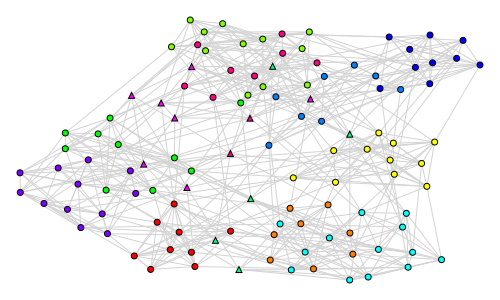

In [5]:
## read graph and communities
cfg = ig.Graph.Read_Ncol(datadir+'Football/football.edgelist',directed=False)
c = np.loadtxt(datadir+'Football/football.community',dtype='uint16',usecols=(0))
cfg.vs['community'] = [c[int(x['name'])] for x in cfg.vs]

## plot the College Football Graph
## show communities in dfferent colors
## show known anomalies as triangles
cfg.vs['shape'] = 'circle'
cfg.vs['anomaly'] = 0
pal = ig.RainbowPalette(n=max(cfg.vs['community'])+1) 
cfg.vs['color'] = [pal.get(int(i)) for i in cfg.vs['community']]
for v in cfg.vs:
    if v['community'] in [5,10] or v['name'] in ['28','58']:
        v['shape']='triangle'
        v['anomaly']=1
ly = cfg.layout_fruchterman_reingold()
ig.plot(cfg, layout=ly, bbox=(0,0,500,300), vertex_size=6, edge_color='lightgray')


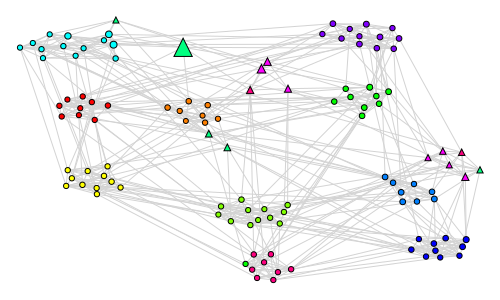

In [9]:
## run ECG and return one of the two "refuse to cluster" scores
ecg = cfg.community_ecg(final='leiden', refuse_score=True, ens_size=32)
cfg.vs['ecg'] = ecg.membership

## pick one of the two here:
#cfg.vs['refuse_score'] = ecg.refuse_overall
cfg.vs['refuse_score'] = ecg.refuse_community

cfg.es['weight'] = ecg.W
cfg.vs['size'] = 6
ly = cfg.layout_fruchterman_reingold(weights='weight')

## re-size nodes w.r.t. score
m = np.min(cfg.vs['refuse_score'])
M = np.max(cfg.vs['refuse_score'])
cfg.vs['size'] = 5*(1+1.5*(cfg.vs['refuse_score'] - m)/(M-m)**2)
## plot
ig.plot(cfg, layout=ly, bbox=(0,0,500,300), edge_color='lightgray')

11
115 407


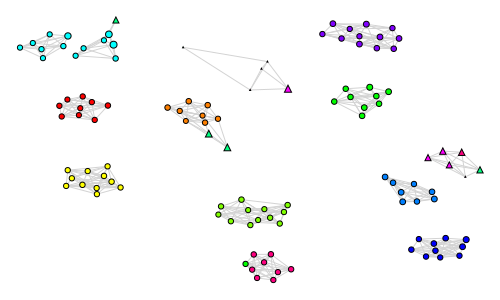

In [29]:
# Single linkage ECG
s = np.sort(np.array(list(set(ecg.W))))
print(len(s))
_g = cfg.copy()
i = 5
t = s[i:i+1]
E = [e for e in _g.es if e['weight']<t]
_g.delete_edges(E)
for v in _g.vs: 
    if v['refuse_score']>.1:
        v['size'] = 1
#g.delete_vertices(V)
print(_g.vcount(), _g.ecount())
ig.plot(_g, layout=ly, bbox=(0,0,500,300), edge_color='lightgray')


## ABCD+o benchmark graphs

The ABCD model (Artificial Benchmark for Community Detection) provides a fast way to generate graphs with properties such as community structure, power law degree and community size distributiions and outlier (non-community) nodes. We consider a few such graphs with:
* 1000 nodes
* 950 nodes in communities, 50 "outlier" nodes (not strongly in a community)
* varying noise level (30%, 40% or 50%); this is the proportion of edges **between** communities

In the experiments below, when computing ARI, we group all outlier nodes are a single "community".


In [30]:
## read graph and communities (pick noise value below)
noise = 40 ## pick 30, 40 or 50

gfn = datadir+'ABCDo/Noise_'+str(noise)+'/edge.dat'
cfn = datadir+'ABCDo/Noise_'+str(30)+'/com.dat'
g = ig.Graph.Read_Ncol(gfn,directed=False)
c = np.loadtxt(cfn,dtype='uint16',usecols=(1))
g.vs['community'] = [c[int(x['name'])-1]-1 for x in g.vs]
g.vs['size'] = 5
g.es['color'] = 'grey'
cls = ['red','green','blue','gold','purple','black','brown','cyan','magenta']
g.vs['color'] = [cls[i] for i in g.vs['community']]


We plot the graph with Fruchterman-Reingold (FR) layout. Communities are shown in color and outliers as triangles.

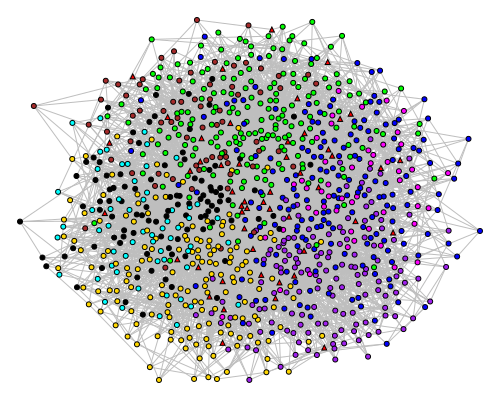

In [31]:
## FR layout plot
## we show communities with colors, outliers with triangles

ly = g.layout_fruchterman_reingold()
g.vs['shape'] = 'circle'
g.vs['anomaly'] = 0
for v in g.vs:
    if v['community']==0:
        v['shape'] = 'triangle'
        v['anomaly'] = 1
ig.plot(g, layout=ly, bbox=(0,0,500,400))

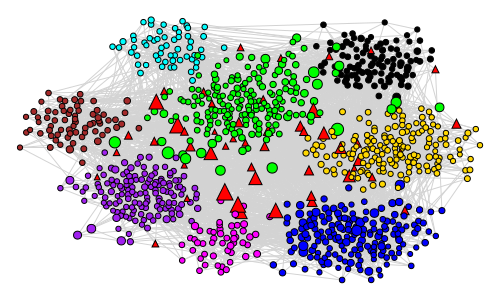

In [37]:
## run ECG
ecg = g.community_ecg(ens_size=32, final='leiden', resolution=1.0, refuse_score=True)
g.vs['ecg'] = ecg.membership

## pick one
#g.vs['refuse_score'] = ecg.refuse_overall
g.vs['refuse_score'] = ecg.refuse_community

ecg = g.community_ecg(final='leiden', refuse_score=True)
g.es['weight'] = ecg.W
g.vs['ecg'] = ecg.membership
ly = g.layout_fruchterman_reingold(weights='weight')
## re-size nodes w.r.t. score
m = np.min(g.vs['refuse_score'])
M = np.max(g.vs['refuse_score'])
g.vs['size'] = 5*(1+1.5*(g.vs['refuse_score'] - m)/(M-m)**2)
ig.plot(g, layout=ly, bbox=(0,0,500,300), edge_color='lightgray')


In [135]:
# TEMP - single linkage ECG

s = np.sort(np.array(list(set(g.es['weight']))))
x = np.quantile(g.vs['refuse_score'],[.25,.75])
th = 2.5*x[1] - 1.5*x[0] ## as in boxplot, Q3 + 1.5*(Q3-Q1)

for i in range(len(s)):
    _g = g.copy()
    t = s[i:i+1]
    E = [e for e in _g.es if e['weight']<t]
    _g.delete_edges(E)
    for v in _g.vs: 
        if v['refuse_score']>th:
            v['size'] = 1
    ari = ARI([v['community'] for v in _g.vs if v['size']>1] , [v['ecg'] for v in _g.vs if v['size']>1])
    recall = np.sum(np.array(_g.vs['size'])>1) / _g.vcount()
    #ig.plot(_g, layout=ly, bbox=(0,0,500,300), edge_color='lightgray')
    print(i,recall, ari)

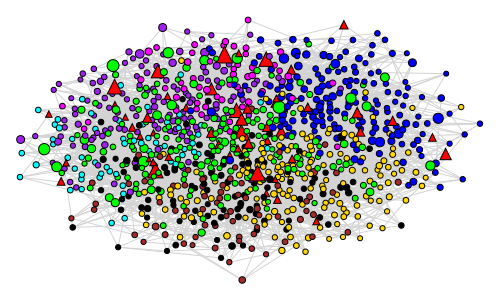

1000 0.9092654030906064
941 0.9593137125650147
939 0.9604557996088443
938 0.9620723130604142
934 0.961764148851007


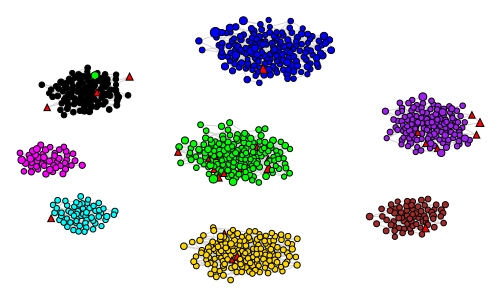

In [152]:
ensemble_size = 32
n_votes_cutoff = 3 ## drop edges if this number of votes or less
minimum_weight = 0.01
edge_th = minimum_weight + (n_votes_cutoff/ensemble_size)*(1-minimum_weight)

_g = g.copy()
_vc = _g.vcount()
print(_g.vcount(), ARI(_g.vs['community'], _g.vs['ecg']))

while True:

    ecg = _g.community_ecg(final='leiden', refuse_score=True, ens_size=ensemble_size, min_weight = minimum_weight)
    _g.es['weight'] = ecg.W
    _g.vs['ecg'] = ecg.membership
    _g.vs['refuse'] = ecg.refuse_community
    x = np.quantile(_g.vs['refuse_score'],[.25,.75])
    th = 2.5*x[1] - 1.5*x[0] ## as in boxplot, Q3 + 1.5*(Q3-Q1)
    
    # s = np.sort(np.array(list(set(_g.es['weight']))))
    
    E = [e for e in _g.es if e['weight']<=edge_th]
    _g.delete_edges(E)

    V = np.where(np.array(_g.vs['refuse'])>th)[0]
    _g.delete_vertices(V)
    V = np.where(np.array(_g.degree())==0)[0]
    if len(V)>0:
        _g.delete_vertices(V)
    if _g.vcount()<_vc:
        _vc = _g.vcount()
    else:
        break
    print(_g.vcount(), ARI(_g.vs['community'], _g.vs['ecg']))

ly = _g.layout_fruchterman_reingold(weights='weight')
ig.plot(_g, layout=ly, bbox=(0,0,500,300), edge_color='lightgray')
